# tsrs time series: case comparison

Snapshots and spectra from the `pts` point time series of several runs, overlaid
in one place. `tsrs_spectra.py` and `tsrs_diag.py` remain the command-line paths;
this notebook is the comparison, laid out the way `drlrec_cases.ipynb` is: a case
table at the top, then one figure per question with every case drawn into it.

**How it is organised**

Section 1 (`tsrs_post.process`) is the only expensive cell. It reads each stitched
record **once** — the `lc_*` ones are several GB — and writes everything derived
from it under `data/results/<solver_case>/<run_name>/`:

```
tsrs/<env>/  snap_<plane>_<field>.npy   (nx, nz, nt) float32 fluctuation
             mean_<plane>_<field>.npy   (nx, nz)     the time mean removed
             axes.npz, snap_meta.yml, stitch.yml
             tsrs_<solver_case>.npz     the stitched record, archived
spectra/     one .npz per spectrum, named exactly as `tsrs_spectra.py --results`
             writes them
```

Every figure below reads *those*, memory-mapped, so re-running a plotting cell
costs nothing and never touches the run directory. Everything in section 1 skips
work whose output already exists, so it is cheap to re-run too — pass
`overwrite=True` to force it.

**Conventions**

* One environment per case, `env_001` by default. The others are independent
  samples of the same policy, which is a question for the reward records, not for
  these figures. Environments are addressed by directory name, not by position.
* A fluctuation is `f' = f - <f>_t(x, z)`: the Reynolds decomposition about the
  time mean of **each point**. It is the only convention that removes the steady
  imprint the actuators leave at their fixed `(x, z)`, which would otherwise be
  counted as turbulent energy in a controlled case.
* Wall units are the **reference** `u_tau` (the uncontrolled one, common to every
  case) rather than each case's own. In actual units every case is divided by its
  own `u_tau` and placed on its own `y+` axis, which scales the drag reduction out
  of the picture that is meant to show it. Pass `scale='actual'` for the
  single-case near-wall-cycle view.
* At `y = 0` userbc holds `ux = uz = 0` and drives `uy` with the control signal,
  so only `v` (the actuation) and `p` carry signal there; `u` and `w` are
  roundoff and are not extracted.

## Environment setup

In [1]:
import os

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from postlib.plot import make_style, colorplate as cc
from postlib import tsrs_post as tp

# not plt_setUp(): these are multi-panel figures and its 30 pt axis labels do
# not fit in a 4-inch panel
plt.rc('font', family='serif', size=11)
plt.rc('axes', labelsize=12, linewidth=1)
plt.rc(('xtick', 'ytick'), labelsize=10)

run_path = '../runs/'
fig_path = 'Figs/'
os.makedirs(fig_path, exist_ok=True)

# Categorical slots in fixed order, never cycled, each with its own marker so
# identity survives colour-vision deficiency and greyscale printing.
STYLE_A = make_style(cc.blue, 0.9, 'o', 'A')
STYLE_B = make_style(cc.red, 0.9, 'X', 'B')
STYLE_C = make_style(cc.deepgreen, 0.9, 'D', 'C')
STYLE_D = make_style(cc.deeppurple, 0.9, 's', 'D')

## Add your case

One row per run. `case` is the `runs/` folder; everything else is resolved from
the data — `eval/` vs the case root, the solver case name, the reference `u_tau`,
the sensing planes. Optional per-row keys:

* `env` — a different environment for that case alone (default `env_001`)
* `y_planes` — the plane list the run actually sampled, for a case whose
  `current_conf.yml` was edited after it ran. Without it such a case fails to
  stitch with `grid mismatch`; it is not needed when the config still matches.

In [2]:
SAVE_IMG = True
HEAD = 'TSRS'

CASE_TABLE = [
    dict(case='mc-noctrl', label='uncontrolled', style=STYLE_A),
    dict(case='oc-mc-dr',  label='opposition',   style=STYLE_B),
    dict(case='lc_omega1_SS_oc_solonek', label='OC (large box)', style=STYLE_C),
]

# The two planes of interest: the wall, and the DRL sensing plane.
PLANES = (0.0, 15.0)
FIELD = 'u'          # variable the spectra and correlations are of
SCALE = 'reference'  # 'reference' compares cases; 'actual' is the per-case view

# Brown & Thomas-style long-time correlation: signed streamwise wall shear
# tau_xw against u at the listed wall-normal planes.  The reconstruction
# needs y+=0 plus two off-wall planes (normally y+=2,5), so cases without
# that stencil are reported as unavailable rather than approximated.
WALL_VELOCITY = dict(velocity='u', tau_component='u',
                     planes=(2.0, 5.0, 10.0, 15.0, 30.0, 50.0),
                     nwall=3, max_lag_time=20.0, x_shift=0, z_shift=0)

cases = tp.resolve_all(CASE_TABLE, runs_dir=run_path)

mc-noctrl                    env_001  case=phill  stitched  -> /home/yuninw/codes/drl/1_Nek/nek_power_saving/data/results/phill/mc-noctrl
oc-mc-dr                     env_001  case=phill  stitched  -> /home/yuninw/codes/drl/1_Nek/nek_power_saving/data/results/phill/oc-mc-dr
lc_omega1_SS_oc_solonek      env_001  case=tcf  stitched  -> /home/yuninw/codes/drl/1_Nek/nek_power_saving/data/results/tcf/lc_omega1_SS_oc_solonek


## 1. Stitch, extract, transform, archive

The one expensive cell. Per case: stitch the `pts` files if there is no `.npz`
yet, read it once, write the per-variable snapshots and the spectra, then copy
the record into the results folder and drop it from memory before the next case.

Re-running is cheap: each step reports what it skipped. `stitch.yml` records the
size and mtime of the archived record, so a source that has been restitched is
noticed and the archive replaced rather than left stale.

In [3]:
OVERWRITE = False

tp.process(cases, planes=PLANES, field=FIELD, quantities=('uu', 'uv'),
           scale=SCALE, wall_velocity=WALL_VELOCITY, overwrite=OVERWRITE)


=== mc-noctrl (uncontrolled) / env_001 ===
env_001: tsrs_phill.npz exists, skipping (overwrite=True to redo)
  snapshots: /home/yuninw/codes/drl/1_Nek/nek_power_saving/data/results/phill/mc-noctrl/tsrs/env_001 exists, skipping (overwrite=True to redo)
  spectra: already in /home/yuninw/codes/drl/1_Nek/nek_power_saving/data/results/phill/mc-noctrl/spectra, skipping (overwrite=True to redo)
  archive: tsrs_phill.npz is current, skipping

=== oc-mc-dr (opposition) / env_001 ===
env_001: tsrs_phill.npz exists, skipping (overwrite=True to redo)
  snapshots: /home/yuninw/codes/drl/1_Nek/nek_power_saving/data/results/phill/oc-mc-dr/tsrs/env_001 exists, skipping (overwrite=True to redo)
  spectra: already in /home/yuninw/codes/drl/1_Nek/nek_power_saving/data/results/phill/oc-mc-dr/spectra, skipping (overwrite=True to redo)
  archive: tsrs_phill.npz is current, skipping

=== lc_omega1_SS_oc_solonek (OC (large box)) / env_001 ===
env_001: tsrs_tcf.npz exists, skipping (overwrite=True to redo)
 

{'mc-noctrl': {'id': 'mc-noctrl',
  'label': 'uncontrolled',
  'style': {'lw': 2.0,
   'c': '#2E59A7',
   'linestyle': '-',
   'alpha': 0.9,
   'marker': 'o',
   'markersize': 7.0,
   'markevery': 20,
   'label': 'A'},
  'runs_dir': PosixPath('../runs'),
  'case_path': PosixPath('../runs/mc-noctrl'),
  'data_path': PosixPath('../runs/mc-noctrl/eval'),
  'env': 'env_001',
  'env_dir': PosixPath('../runs/mc-noctrl/eval/env_001'),
  'config': {'simulation': {'CASENAME': 'phill',
    'solver_version': 'v19',
    'exeName': 'nek5000',
    'nzs': 1,
    'nxs': 1,
    'out_log': 'logfile',
    'host': 'localhost',
    'hostfile': '',
    'compile_path': 'envs/cases/mini_channel',
    'restart_folder': 'data/restarts/rs6_mini_Channel',
    'shared_data_path': '',
    'shared_data_link': True,
    'nproc': 10,
    'TOTCTRL': 220,
    'ndrl': 1,
    'znmf_avg': 0,
    'target_cfl': 2.0,
    'y_sensing': 15.0,
    'y_planes': [0, 2, 5, 7, 10, 15, 30, 45, 50, 75, 100, 150],
    'retau': 180.0,
   

### What was extracted

Which planes each case actually has, and how much of each record is on disk. A
requested plane that a case does not hold is **dropped, not substituted**:
`oc-mc-dr` starts at `y+ = 5`, and drawing that as "the wall" would be a quietly
wrong figure rather than a missing one.

In [4]:
rows = []
for cid, e in cases.items():
    m = tp.read_snap_meta(e)
    for tag, p in m['planes'].items():
        rows.append({
            'label': e['label'], 'case': cid, 'env': m['env'],
            'y+': p['yplus'], 'y': round(p['y'], 5),
            'fields': ','.join(p['fields']),
            'nx x nz x nt': f"{m['nx']} x {m['nz']} x {m['nt']}",
            't': f"{m['t0']:.1f} - {m['t1']:.1f}",
            'Re_tau': m['retau'], 'u_tau,ref': m['utau_ref'],
            'Lx+': round(m['Lx'] * m['retau']), 'Lz+': round(m['Lz'] * m['retau']),
        })
pd.DataFrame(rows)

,label,case,env,y+,y,fields,nx x nz x nt,t,Re_tau,"u_tau,ref",Lx+,Lz+
0,uncontrolled,mc-noctrl,env_001,0.0,0.00000,"v,p",20 x 20 x 2500,399.0 - 474.0,180.0,0.065,481,144
1,uncontrolled,mc-noctrl,env_001,15.0,0.08333,"u,v,w,p",20 x 20 x 2500,399.0 - 474.0,180.0,0.065,481,144
2,opposition,oc-mc-dr,env_001,15.0,0.08333,"u,v,w,p",20 x 20 x 2500,399.0 - 474.0,180.0,0.065,481,144
3,OC (large box),lc_omega1_SS_oc_solonek,env_001,0.0,0.00000,"v,p",80 x 72 x 3529,476.1 - 716.0,207.0,0.063,1300,650
4,OC (large box),lc_omega1_SS_oc_solonek,env_001,15.0,0.07246,"u,v,w,p",80 x 72 x 3529,476.1 - 716.0,207.0,0.063,1300,650


**Read `Lx+` and `Lz+` before anything below.** Spectra only say something when
the box is larger than the structures. For a minimal channel (`Lx+ = 481`,
`Lz+ = 144`) the near-wall streaks — `λ_z+ ≈ 100`, `λ_x+ ≈ 1000` — do not fit, so
the premultiplied spectra rise monotonically to the fundamental with no peak, and
`ρ_uu(Δx)` is still well above zero at half the box. That is the box talking, not
the flow. Nineteen periodic points in `z` also leave only **nine** spanwise
wavenumbers to map. The `lc_*` cases resolve both scales and are the ones to draw
conclusions from.

## 2. The sensing plane, `y+ = 15`

One instant, rows are cases, columns are variables. The colour scale is shared
down each column, which is the point of the figure: a controlled case is supposed
to look *weaker* than the uncontrolled one, and a per-panel scale normalises
exactly that difference away. `clim='panel'` restores it when a faint field needs
its own contrast.

The instant is a *physical time* every case covers, not a shared index — the runs
cover different windows.

[WARN] the cases do not overlap in time (latest start 476.1 > earliest end 474.0); each panel will use its own nearest snapshot
  -> Figs/TSRS_snap_yp15.jpg


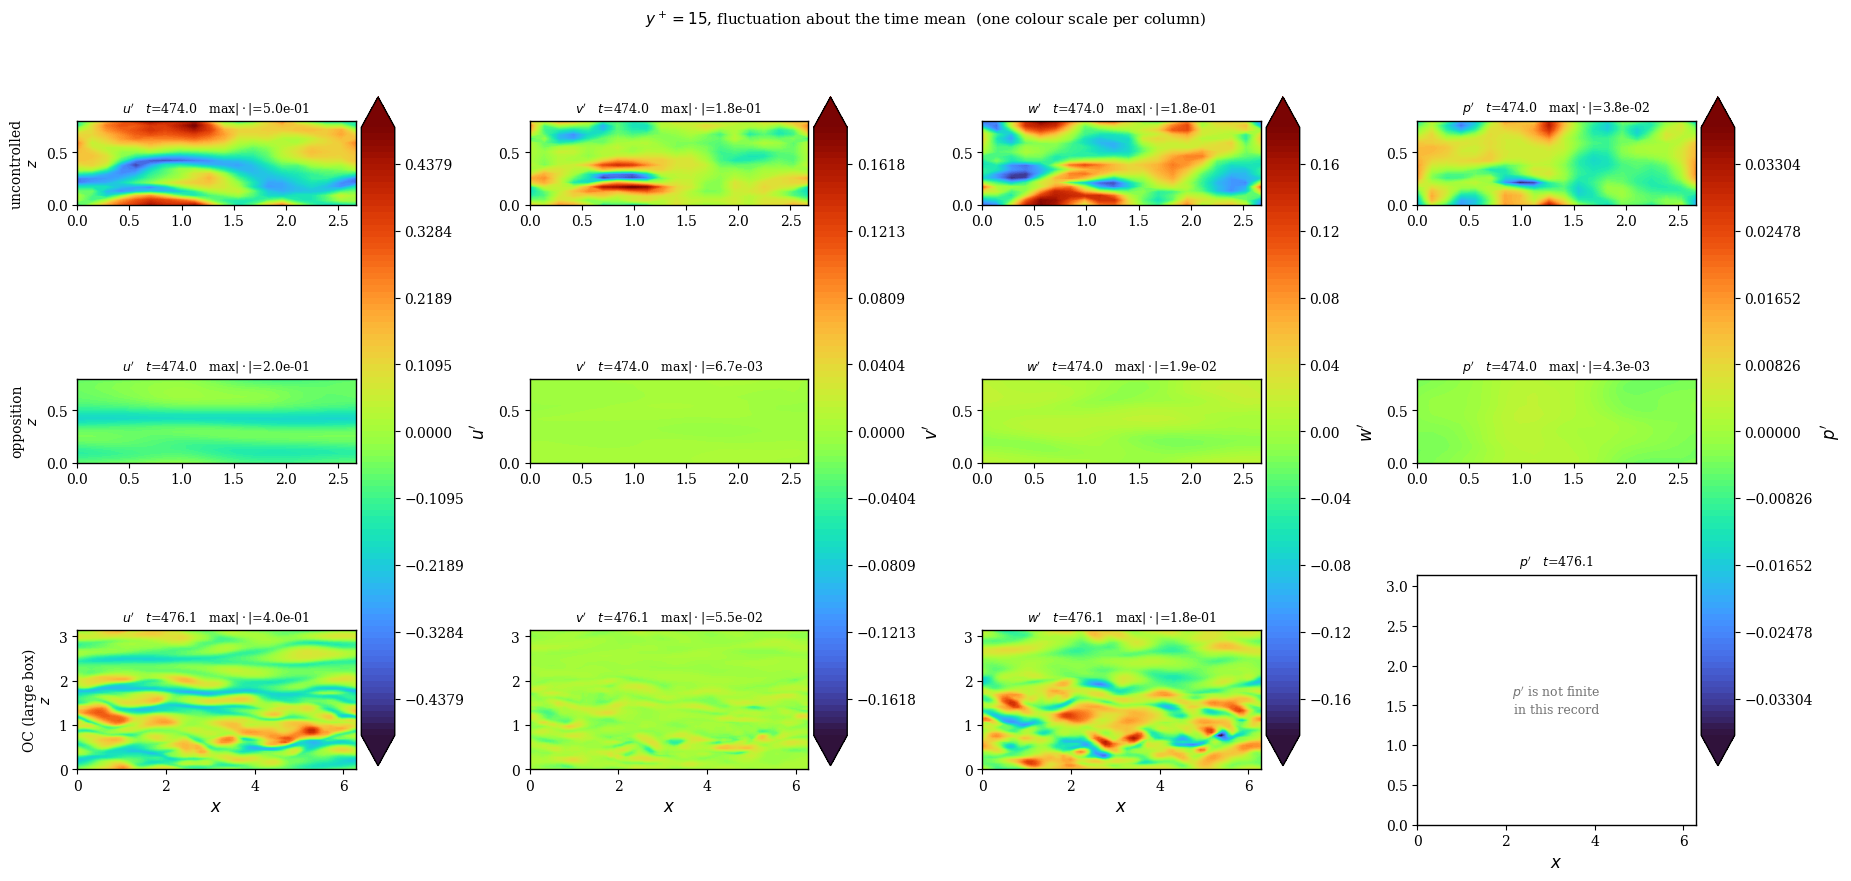

In [5]:
T_SNAP = None   # a physical time, or None for the last one every case reaches

fig = tp.plot_snapshot_grid(cases, yplus=15.0, fields=['u', 'v', 'w', 'p'],
                            t=T_SNAP, clim='shared',
                            save=f'{fig_path}{HEAD}_snap_yp15.jpg' if SAVE_IMG else None)
plt.show()

## 3. The wall plane, `y = 0`

Only `v` and `p` live here. `v'` **is** the actuation, so this panel is the
control signal as the flow received it; in an uncontrolled case it is identically
zero and the panel says so instead of rendering roundoff as structure.

[WARN] the cases do not overlap in time (latest start 476.1 > earliest end 474.0); each panel will use its own nearest snapshot
  -> Figs/TSRS_snap_yp0.jpg


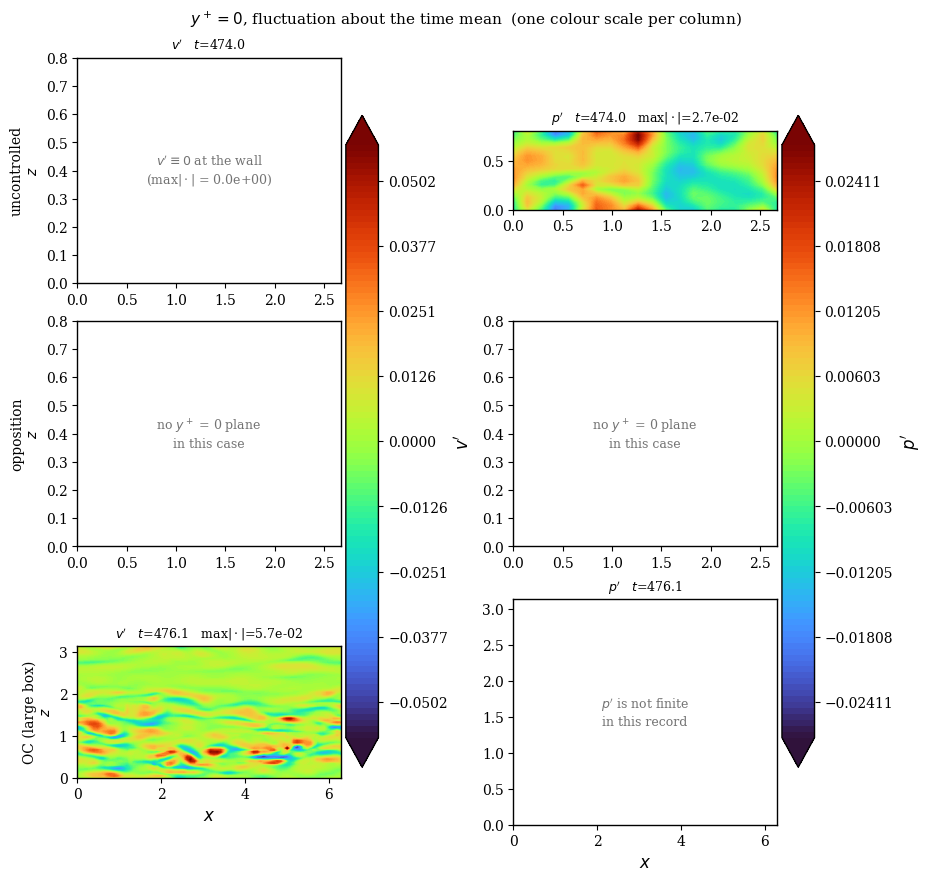

In [6]:
fig = tp.plot_snapshot_grid(cases, yplus=0.0, fields=['v', 'p'], t=T_SNAP,
                            clim='shared',
                            save=f'{fig_path}{HEAD}_snap_yp0.jpg' if SAVE_IMG else None)
plt.show()

## 4. [Optional] Animations

One gif per case and quantity, into `data/results/<case>/<run>/figs/anim/`.

The colour scale is fixed over the whole window rather than per frame: a
per-frame scale makes the field pulse in and out of saturation and hides the
intensity changes the animation is for. Frames are subsampled — all 3529 of an
`lc_*` record is a 100 MB gif no one opens.

In [7]:
MAKE_GIFS = False
ANIM = [(15.0, 'u'), (15.0, 'v'), (0.0, 'v')]

if MAKE_GIFS:
    for cid, e in cases.items():
        for yp, name in ANIM:
            if tp.load_snapshot(e, yp, name) is None:
                continue
            tp.animate(e, yplus=yp, field=name, nframes=200, fps=15)

In [8]:
# Display one of the animations inline.  Set MAKE_GIFS = True above and re-run
# that cell first -- with it False there is nothing on disk to show yet.
from IPython.display import Image, display

for cid, e in cases.items():
    hits = sorted((e['figs_dir'] / 'anim').glob('*.gif'))
    if hits:
        print(hits[0])
        display(Image(str(hits[0])))
        break
else:
    print('no animations on disk yet -- set MAKE_GIFS = True above and re-run')

FileNotFoundError: No such file or directory: '/home/yuninw/codes/drl/1_Nek/nek_power_saving/data/results/phill/mc-noctrl/figs/anim/mc-noctrl_yp15_u.gif'

FileNotFoundError: No such file or directory: '/home/yuninw/codes/drl/1_Nek/nek_power_saving/data/results/phill/mc-noctrl/figs/anim/mc-noctrl_yp15_u.gif'

<IPython.core.display.Image object>

## 5. Power spectral density

The premultiplied spectrum over `(λ_z+, y+)`, both axes logarithmic — the
standard wall-turbulence presentation. The ridge traces the energetic scale at
each height, so a controller shows up as a shift or a weakening of that ridge.

Top row `k_z Φ_uu+`, bottom row `−k_z Φ_uv+`, one case per column with one colour
scale per row. The sign on `uv` is flipped for the picture only — the
co-spectrum is negative, and `−uv` is the usual presentation; the archived data
stays sign-true.

`y+ = 0` cannot be drawn on a log axis, and `u` is identically zero at the wall
anyway. A blank band at the bottom of a column means that case has no planes
that low, not that the energy vanishes there.

  -> Figs/TSRS_mapz.jpg


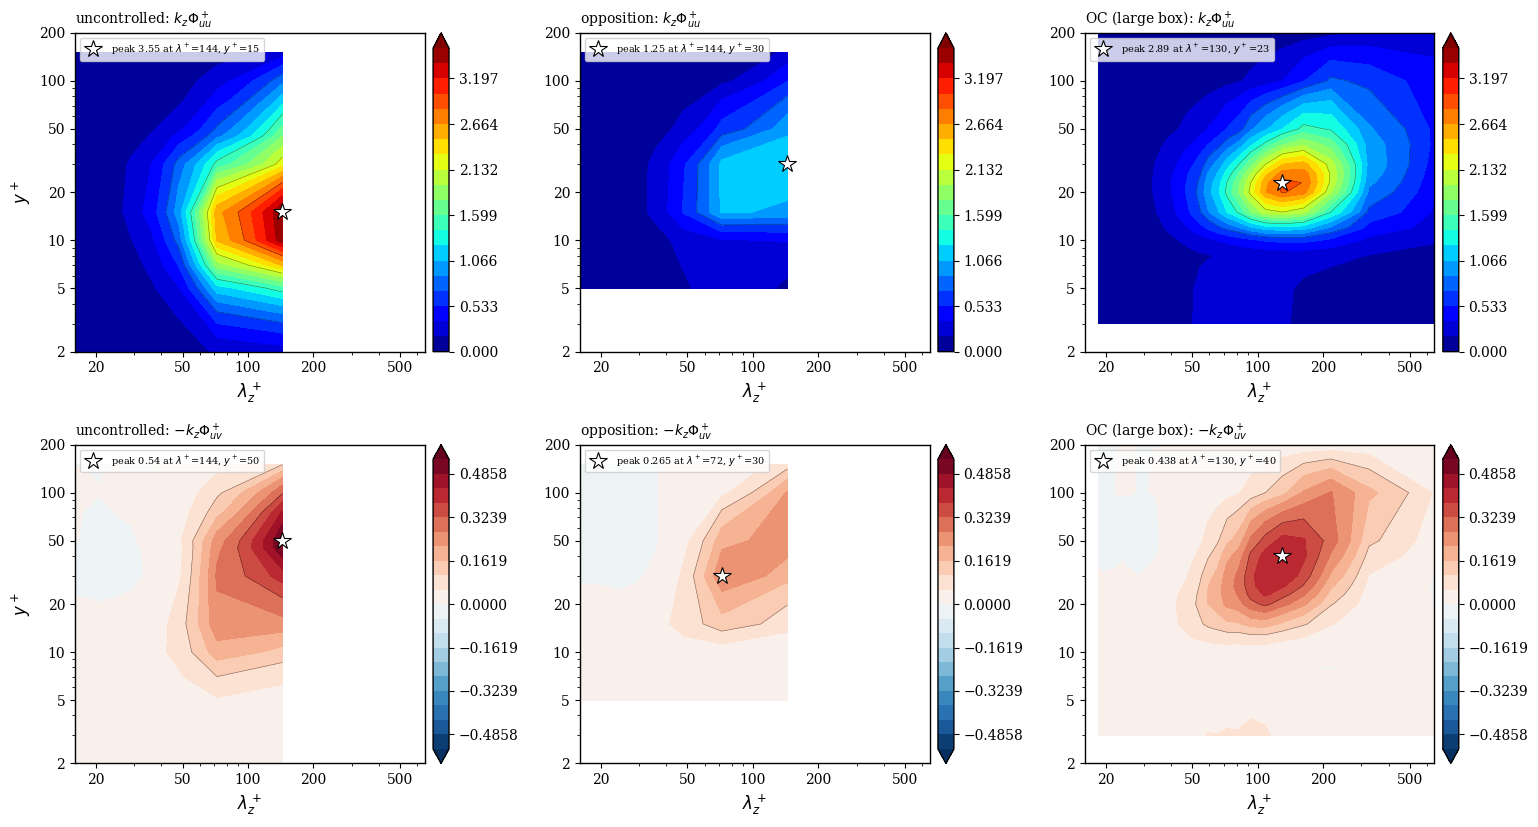

In [9]:
fig = tp.plot_map(cases, quantities=('uu', '-uv'), map_dir='z', field=FIELD,
                  scale=SCALE, style='contour',
                  save=f'{fig_path}{HEAD}_mapz.jpg' if SAVE_IMG else None)
plt.show()

  -> Figs/TSRS_mapz_mesh.jpg


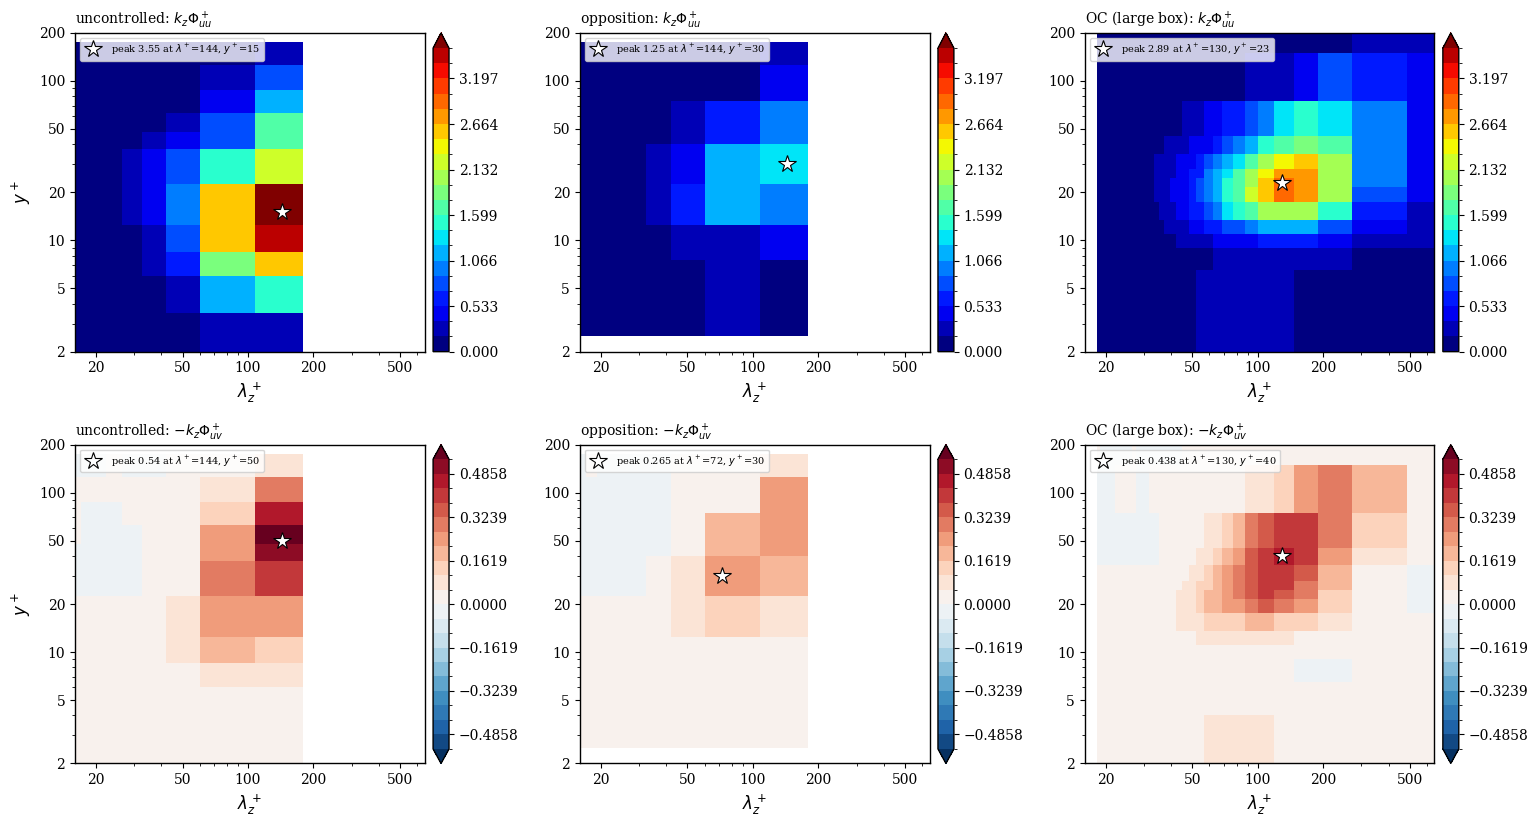

In [10]:
# The same map with one cell per sample, claiming no resolution it does not
# have.  Worth a look on the minimal-channel cases, where 'contour' interpolates
# nine wavenumbers into what reads as a smooth field.
fig = tp.plot_map(cases, quantities=('uu', '-uv'), field=FIELD, scale=SCALE,
                  style='mesh',
                  save=f'{fig_path}{HEAD}_mapz_mesh.jpg' if SAVE_IMG else None)
plt.show()

### Where the energy peaks

The single number to compare across cases: the height and spanwise wavelength of
the most energetic scale, and how much energy is in it.

In [11]:
rows = []
for qty in ('uu', 'uv'):
    for cid, e in cases.items():
        d = tp.load_spectrum(e, f'mapz_{tp.map_label(FIELD, qty)}', SCALE)
        lam, yp, val = d['peak']
        rows.append({'label': e['label'], 'quantity': tp.map_label(FIELD, qty),
                     'peak k Phi+': round(float(val), 4),
                     'at lambda_z+': round(float(lam)),
                     'at y+': round(float(yp), 4),
                     'u_tau': round(float(d['utau']), 5),
                     'DR [%]': (None if not np.isfinite(d['drag_reduction_pct'])
                                else round(float(d['drag_reduction_pct']), 2))})
peaks = pd.DataFrame(rows)
if SAVE_IMG:
    peaks.to_csv(f'{fig_path}{HEAD}_peaks.csv', index=False)
peaks

,label,quantity,peak k Phi+,at lambda_z+,at y+,u_tau,DR [%]
0,uncontrolled,uu,3.5526,144,15.0,0.065,-2.01
1,opposition,uu,1.2498,144,30.0,0.065,32.17
2,OC (large box),uu,2.8937,130,23.0,0.063,31.32
3,uncontrolled,uv,-0.5398,144,50.0,0.065,-2.01
4,opposition,uv,-0.2652,72,30.0,0.065,32.17
5,OC (large box),uv,-0.4384,130,40.0,0.063,31.32


## 6. Two-point correlation

One subfigure per case, at `y+ = 15`. Solid is spanwise, dashed streamwise; the
faint grey curves are the `extra_planes` for context.

The separation axis stops at half the period, which is all a periodic box can
say. `ρ_uu(Δz)` dipping to a negative minimum near `Δz+ ≈ 50` is the signature of
the streak spacing — the low-speed streak flanked by high-speed ones. Where `ρ`
is still well above zero at the end of the axis, the structure is longer than the
box and the curve is measuring the box.

  -> Figs/TSRS_corr_yp15.jpg


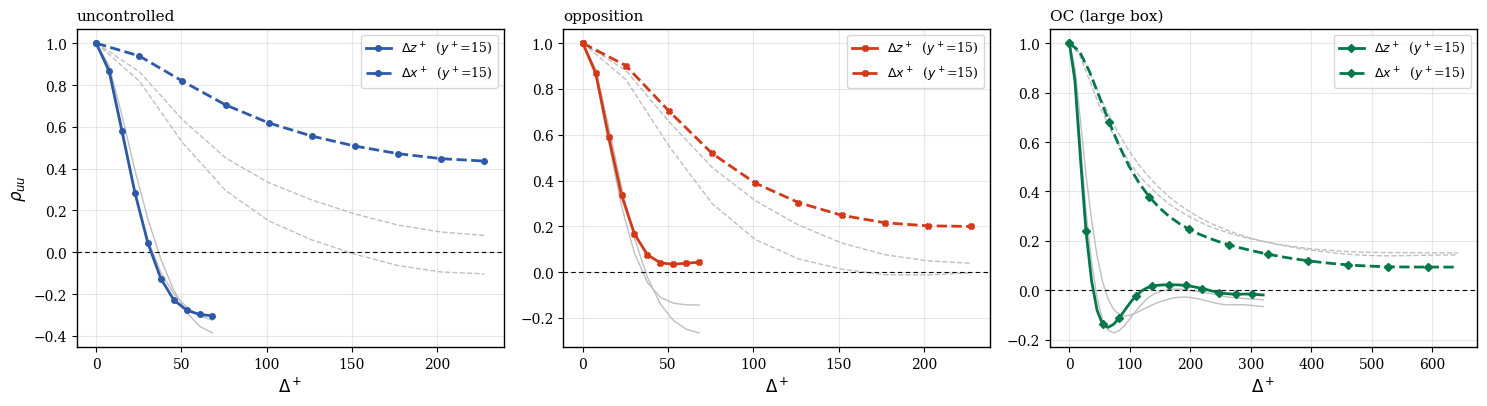

In [12]:
fig = tp.plot_correlation(cases, yplus=15.0, field=FIELD, scale=SCALE,
                          directions=('z', 'x'), extra_planes=(30.0, 50.0),
                          save=f'{fig_path}{HEAD}_corr_yp15.jpg' if SAVE_IMG else None)
plt.show()

## 7. Wall-shear / streamwise-velocity time correlation

Brown and Thomas correlate the signed streamwise wall shear with streamwise velocity
at increasing wall-normal positions. Here the wall plane replaces their shear probe and
the complete TSRS plane replaces each hot wire:

$$R_{\tau_{xw},u}(T;y) = \frac{\langle \tau'_{xw}(x,z,t)u'(x,z,y,t+T)\rangle}{\tau_{xw,\mathrm{rms}}u_{\mathrm{rms}}(y)}.$$

`tau_xw` is reconstructed as `nu * du/dy` from the wall, `y+=2`, and `y+=5`
planes using a nonuniform one-sided derivative. Means are removed at each `(x,z)`
before correlation, and lagged samples overlap but never wrap across the finite record.
The dots mark the maximum positive correlation for each plane. A case without this
near-wall stencil is left blank rather than being silently replaced by another signal.

In [ ]:
fig = tp.plot_wall_velocity_correlation(
    cases, yplus=WALL_VELOCITY['planes'], velocity=WALL_VELOCITY['velocity'],
    tau_component=WALL_VELOCITY['tau_component'], scale=SCALE,
    save=f'{fig_path}{HEAD}_wallcorr_taux_u.jpg' if SAVE_IMG else None)
plt.show()

In [ ]:
# The archived stencil and peak table make the derivative resolution and the
# inferred delay explicit instead of reading either one off the plot.
rows = []
for cid, e in cases.items():
    d = tp.load_wall_velocity_correlation(
        e, velocity=WALL_VELOCITY['velocity'],
        tau_component=WALL_VELOCITY['tau_component'], scale=SCALE, verbose=False)
    if d is None:
        continue
    for iy, yp in enumerate(d['yplus']):
        rows.append({'label': e['label'], 'y+': float(yp),
                     'peak R': float(d['peak_rho'][iy]),
                     'at T+': float(d['peak_lag_plus'][iy]),
                     'at T': float(d['peak_lag_time'][iy])})
wallcorr_peaks = pd.DataFrame(rows)
wallcorr_peaks

## 8. What is on disk

Everything the notebook wrote, per case. The stitched record is **copied** into
the results folder, not linked: this tree is what survives the run directory
being cleared.

In [13]:
rows = []
for cid, e in cases.items():
    for sub in ('tsrs', 'spectra', 'figs'):
        d = e['tsrs_dir'] if sub == 'tsrs' else e['root'] / sub
        files = [q for q in d.rglob('*') if q.is_file()] if d.is_dir() else []
        rows.append({'label': e['label'], 'dir': sub, 'files': len(files),
                     'MB': round(sum(q.stat().st_size for q in files) / 1e6, 1),
                     'path': str(d)})
pd.DataFrame(rows)

,label,dir,files,MB,path
0,uncontrolled,tsrs,16,216.1,/home/yuninw/codes/drl/1_Nek/nek_power_saving/...
1,uncontrolled,spectra,8,0.1,/home/yuninw/codes/drl/1_Nek/nek_power_saving/...
2,uncontrolled,figs,0,0.0,/home/yuninw/codes/drl/1_Nek/nek_power_saving/...
3,opposition,tsrs,12,128.1,/home/yuninw/codes/drl/1_Nek/nek_power_saving/...
4,opposition,spectra,8,0.1,/home/yuninw/codes/drl/1_Nek/nek_power_saving/...
5,opposition,figs,0,0.0,/home/yuninw/codes/drl/1_Nek/nek_power_saving/...
6,OC (large box),tsrs,16,5366.5,/home/yuninw/codes/drl/1_Nek/nek_power_saving/...
7,OC (large box),spectra,14,0.3,/home/yuninw/codes/drl/1_Nek/nek_power_saving/...
8,OC (large box),figs,0,0.0,/home/yuninw/codes/drl/1_Nek/nek_power_saving/...


### Reading the saved data directly

```python
e = cases['mc-noctrl']

# a snapshot series, memory-mapped: (nx, nz, nt), fluctuation about the time mean
up = tp.load_snapshot(e, yplus=15, field='u')
axes = tp.load_axes(e)                       # x, z, t, y, yplus, retau
raw = up[:, :, 100] + tp.load_mean(e, 15, 'u')   # back to the raw field

# a spectrum, self-contained: it carries the scalars it was scaled with, so it
# can be replotted in other wall units without the run it came from
d = tp.load_spectrum(e, 'mapz_uu', 'reference')
d['kPhi_plus']                       # as plotted, / u_tau^2
d['kPhi'] / other_utau ** 2          # rescaled to any other u_tau
d['utau'], d['utau_ref'], d['retau'], d['nu']
```

The rest of the case root — the model, the config, the reward records — is filled
by `utils/collect-results --run_name <case>` and `drlrec_cases.ipynb`.